In [ ]:
# Instalando bibliotecas, As linhas estão comentadas (#), então o comando não será executado.

# !pip install pandas
# instalando pandas para tratamento de dados

# !pip install scikit-learn
# Instala a biblioteca scikit-learn, usada para criar modelos de Machine Learning.

# !pip install matplotlib
# Instala a biblioteca matplotlib, utilizada para criar gráficos e visualizações de dados.

# !pip install seaborn
# Instala a biblioteca seaborn, usada para criar gráficos estatísticos mais avançados.



In [ ]:
# IMPORTAÇÃO DAS BIBLIOTECAS
# ================================

# Pandas → manipulação e análise de dados em formato de DataFrame
import pandas as pd

# Matplotlib → biblioteca base para criação de gráficos
import matplotlib.pyplot as plt

# Seaborn → biblioteca de visualização baseada no matplotlib, com gráficos mais sofisticados
import seaborn as sns

# NearestNeighbors → algoritmo KNN usado para encontrar registros mais semelhantes
from sklearn.neighbors import NearestNeighbors

# StandardScaler → normaliza os dados para evitar distorção entre variáveis
# LabelEncoder → transforma variáveis categóricas em valores numéricos
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [ ]:



import os
import sys

# 1. Força o uso do Java correto (Ignora o seu Java 26 do sistema)
os.environ["JAVA_HOME"] = r"C:\Java\jdk-17"

# 2. Configura o Hadoop (Necessário para não dar erro de permissão no Windows)
os.environ["HADOOP_HOME"] = r"C:\hadoop"

# 3. Atualiza o PATH para o Python encontrar os binários
os.environ["PATH"] = os.environ["JAVA_HOME"] + "\\bin;" + os.environ["HADOOP_HOME"] + "\\bin;" + os.environ["PATH"]

os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

from pyspark.sql import SparkSession

# 4. Inicia a sessão
try:
    # spark = SparkSession.builder \
    #     .appName("TesteSpark") \
    #     .master("local[*]") \
    #     .getOrCreate()

    spark = SparkSession.builder \
    .appName("ProjetoCNPJ") \
    .config("spark.driver.host", "127.0.0.1") \
    .config("spark.driver.bindAddress", "127.0.0.1") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .getOrCreate()

    print("✅ Spark iniciado com sucesso!")
    spark.range(3).show()
except Exception as e:
    print(f"❌ Erro ao iniciar: {e}")

✅ Spark iniciado com sucesso!
+---+
| id|
+---+
|  0|
|  1|
|  2|
+---+



In [ ]:
# Definição dos nomes das colunas que serão atribuídas ao arquivo de países
cols_paises = [
    "CODIGO",
    "DESCRICAO"
]

# Leitura do arquivo CSV de países utilizando pandas
PAISEES = pd.read_csv(
    "/content/drive/My Drive/ProjetoAplicadoII/01_raw_zone/Paises/F.K03200$Z.D60314.PAISCSV",
    sep=";",
    encoding="cp1252",
    header=None,
    names=cols_paises
)

# Conversão do DataFrame pandas para DataFrame Spark
df2 = spark.createDataFrame(PAISEES)

# Exibição dos dados carregados
PAISEES

,CODIGO,DESCRICAO
0,0,COLIS POSTAUX
1,13,AFEGANISTAO
2,17,ALBANIA
3,20,"ALBORAN-PEREJIL,ILHAS"
4,23,ALEMANHA
...,...,...
250,895,ZONA DO CANAL DO PANAMA
251,990,PROV. DE NAVIOS E AERONAVES
252,997,NAO DECLARADOS
253,998,NAO DECLARADO PRELIMINAR


In [ ]:
# =========================================
# IMPORTAÇÃO DA BASE DE DADOS DE EMPRESAS
# =========================================

# Definição dos nomes das colunas que serão atribuídas ao dataset
cols = [
    "CNPJ_BASICO",
    "RAZAO_SOCIAL",
    "NATUREZA_JURIDICA",
    "QUALIFICACAO_RESPONSAVEL",
    "CAPITAL_SOCIAL",
    "PORTE_EMPRESA",
    "ENTE_FEDERATIVO"
]

# Leitura do arquivo CSV contendo os dados das empresas utilizando pandas
EMPRESAS = pd.read_csv(
    "/content/drive/My Drive/ProjetoAplicadoII/01_raw_zone/Empresas1/K3241.K03200Y1.D60314.EMPRECSV",
    sep=";",            # separador das colunas no arquivo
    encoding="cp1252",  # codificação para leitura correta de caracteres especiais
    header=None,        # indica que o arquivo não possui cabeçalho
    names=cols          # atribui manualmente os nomes das colunas
)

# Visualização das primeiras 10 linhas do DataFrame carregado
display(EMPRESAS.head(10))

,CNPJ_BASICO,RAZAO_SOCIAL,NATUREZA_JURIDICA,QUALIFICACAO_RESPONSAVEL,CAPITAL_SOCIAL,PORTE_EMPRESA,ENTE_FEDERATIVO
0,0,BANCO DO BRASIL SA,2038,10,"120000000000,00",5.0,NaN
1,1,ASSOCIACAO DE AMIGOS DE BAIRRO DO CONJ PAULISTANO,3999,16,"0,00",5.0,NaN
2,2,WM&R EMPREITEIRA DE CONSTRUCAO CIVIL LIMITADA,2240,49,"0,00",5.0,NaN
3,3,CASA CARIDADE LUZETE ROBERTA DE MORAIS CONJ PA...,3999,16,"0,00",5.0,NaN
4,4,ASSOCIACAO DO PEQUENO ADOLECENTE DO CONJ PAULI...,3999,16,"0,00",5.0,NaN
5,5,SERRALHERIA PORTA DE ACO REAL S/C LTDA,2240,28,"0,00",5.0,NaN
6,6,ACADEMIA DE BALLET PAULA FIRETTI LTDA,2062,49,"1000,00",1.0,NaN
7,7,ADVOCACIA BERGANTIN E ASSOCIADOS,2240,49,"0,00",1.0,NaN
8,8,A.R. ZANOTI E SILVA S/C LTDA,2240,49,"0,00",1.0,NaN
9,9,SUWAN REPRESENTACOES LTDA,2240,49,"0,00",1.0,NaN


In [ ]:
# =========================================
# IMPORTAÇÃO DA BASE DE ESTABELECIMENTOS
# =========================================

# Definição da estrutura do dataset de estabelecimentos,
# especificando os nomes de todas as colunas presentes no arquivo
cols_estabelecimentos = [
    "CNPJ_BASICO",
    "CNPJ_ORDEM",
    "CNPJ_DV",
    "IDENTIFICADOR_MATRIZ_FILIAL",
    "NOME_FANTASIA",
    "SITUACAO_CADASTRAL",
    "DATA_SITUACAO_CADASTRAL",
    "MOTIVO_SITUACAO_CADASTRAL",
    "NOME_CIDADE_EXTERIOR",
    "PAIS",
    "DATA_INICIO_ATIVIDADE",
    "CNAE_FISCAL_PRINCIPAL",
    "CNAE_FISCAL_SECUNDARIA",
    "TIPO_LOGRADOURO",
    "LOGRADOURO",
    "NUMERO",
    "COMPLEMENTO",
    "BAIRRO",
    "CEP",
    "UF",
    "MUNICIPIO",
    "DDD_1",
    "TELEFONE_1",
    "DDD_2",
    "TELEFONE_2",
    "DDD_FAX",
    "FAX",
    "CORREIO_ELETRONICO",
    "SITUACAO_ESPECIAL",
    "DATA_SITUACAO_ESPECIAL"
]

# Leitura do arquivo CSV de estabelecimentos utilizando pandas,
# configurando separador, codificação e atribuindo os nomes das colunas definidos
ESTABELECIMENTOS = pd.read_csv(
    "/content/drive/My Drive/ProjetoAplicadoII/01_raw_zone/Estabelecimentos0/K3241.K03200Y0.D50913.ESTABELE",
    sep=";",
    encoding="latin1",
    header=None,
    names=cols_estabelecimentos
)

# Exibição das primeiras linhas do dataset para validação da importação
display(ESTABELECIMENTOS.head())

C:\Users\welli\AppData\Local\Temp\ipykernel_7396\1754509368.py:42: DtypeWarning: Columns (0: NOME_CIDADE_EXTERIOR, 1: DDD_1, 2: TELEFONE_1, 3: TELEFONE_2, 4: FAX, 5: SITUACAO_ESPECIAL) have mixed types. Specify dtype option on import or set low_memory=False.
  ESTABELECIMENTOS = pd.read_csv(


,CNPJ_BASICO,CNPJ_ORDEM,CNPJ_DV,IDENTIFICADOR_MATRIZ_FILIAL,NOME_FANTASIA,SITUACAO_CADASTRAL,DATA_SITUACAO_CADASTRAL,MOTIVO_SITUACAO_CADASTRAL,NOME_CIDADE_EXTERIOR,PAIS,...,MUNICIPIO,DDD_1,TELEFONE_1,DDD_2,TELEFONE_2,DDD_FAX,FAX,CORREIO_ELETRONICO,SITUACAO_ESPECIAL,DATA_SITUACAO_ESPECIAL
0,7396865,1,68,1,NaN,8,20170210,1,NaN,NaN,...,8297,47.0,33851125,47.0,33851125.0,47.0,33851125,NaN,NaN,NaN
1,64904295,18,51,2,NaN,8,20161110,1,NaN,NaN,...,2785,11.0,36491000,31.0,33880436.0,82.0,33118379,CLAUDIO.GIGLIO@CAMIL.COM.BR,NaN,NaN
2,76016369,3,16,2,NaN,4,20231113,63,NaN,NaN,...,7071,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,52302726,1,82,1,NaN,4,20210406,63,NaN,NaN,...,6131,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,7396923,1,53,1,NaN,8,20140115,1,NaN,NaN,...,7107,11.0,69658088,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# =========================================
# IMPORTAÇÃO DAS BIBLIOTECAS NECESSÁRIAS
# =========================================
import pandas as pd
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler, LabelEncoder


# =========================================
# 1. MERGE INICIAL ENTRE ESTABELECIMENTOS E EMPRESAS
# =========================================
# Combina as duas bases utilizando a chave CNPJ_BASICO,
# adicionando informações da empresa (razão social, natureza jurídica e porte)
# aos registros da base de estabelecimentos.
tb_01_01 = ESTABELECIMENTOS.merge(
    EMPRESAS[["CNPJ_BASICO", "RAZAO_SOCIAL", "NATUREZA_JURIDICA", "PORTE_EMPRESA"]],
    how="left",
    on="CNPJ_BASICO"
)


# =========================================
# 2. TRATAMENTO DA COLUNA DE PAÍS
# =========================================
# Remove possíveis decimais do código do país (ex: 249.0 ou 249,0)
# e converte o valor para formato numérico.
tb_01_01["PAIS_INT"] = (
    tb_01_01["PAIS"]
    .astype(str)
    .str.replace(",0", "", regex=False)
    .str.replace(".0", "", regex=False)
)

# Conversão da coluna tratada para número,
# transformando valores inválidos em NaN
tb_01_01["PAIS_INT"] = pd.to_numeric(tb_01_01["PAIS_INT"], errors="coerce")


# =========================================
# 3. MERGE COM A BASE DE PAÍSES
# =========================================
# Junta a base principal com a tabela de países,
# permitindo trazer a descrição do país a partir do código.
tb_01_01 = tb_01_01.merge(
    PAISEES[["CODIGO", "DESCRICAO"]],
    how="left",
    left_on="PAIS_INT",
    right_on="CODIGO"
)


# =========================================
# 4. AJUSTES FINAIS E LIMPEZA DOS DADOS
# =========================================

# Renomeia a coluna DESCRICAO para DS_PAIS para melhor identificação
tb_01_01.rename(columns={"DESCRICAO": "DS_PAIS"}, inplace=True)

# Garantindo que colunas importantes para análise e para o KNN
# estejam em formato correto e não possuam valores nulos
tb_01_01["CNAE_FISCAL_PRINCIPAL"] = tb_01_01["CNAE_FISCAL_PRINCIPAL"].astype(str).fillna("0")
tb_01_01["CNAE_FISCAL_SECUNDARIA"] = tb_01_01["CNAE_FISCAL_SECUNDARIA"].astype(str).fillna("")
tb_01_01["UF"] = tb_01_01["UF"].astype(str).fillna("EX")  # EX representa Exterior


# =========================================
# 5. CRIAÇÃO DO DATAFRAME FINAL PARA ANÁLISE
# =========================================
# Remove registros com valores nulos em campos essenciais
# para garantir qualidade na análise e execução do modelo
teste = tb_01_01.dropna(subset=["NOME_FANTASIA", "RAZAO_SOCIAL", "PORTE_EMPRESA"]).copy()


# =========================================
# 6. LIMPEZA FINAL PARA EXECUÇÃO DO KNN
# =========================================

# Remove registros onde o país ainda esteja nulo,
# pois o modelo precisa dessa informação válida
teste = teste.dropna(subset=["PAIS_INT"])

# Converte a coluna de país para inteiro (int64),
# garantindo compatibilidade e melhor desempenho nas análises
teste["PAIS_INT"] = teste["PAIS_INT"].astype('int64')

In [ ]:
# LISTA DE EMPRESAS PARA PESQUISA DENTRO DO MODELO

# display(teste["CNAE_FISCAL_PRINCIPAL"] == 2])
# Use colchetes duplos para selecionar múltiplas colunas
# Ordenando por PAIS_INT e exibindo as colunas selecionadas
display(teste[["CNAE_FISCAL_PRINCIPAL", "PAIS_INT", "DS_PAIS"]].sort_values(by="DS_PAIS"))

,CNAE_FISCAL_PRINCIPAL,PAIS_INT,DS_PAIS
198686,9900800,23,ALEMANHA
423259,4789002,23,ALEMANHA
1968000,4663000,63,ARGENTINA
148623,9900800,72,AUSTRIA
149541,9900800,81,BANGLADESH
317829,5111100,87,BELGICA
3575600,4211101,97,BOLIVIA
148723,4329199,80,"Bahrein, Ilhas"
174103,9900800,158,CHILE
207385,5111100,158,CHILE


Assertividade: Similaridade de 71.72%


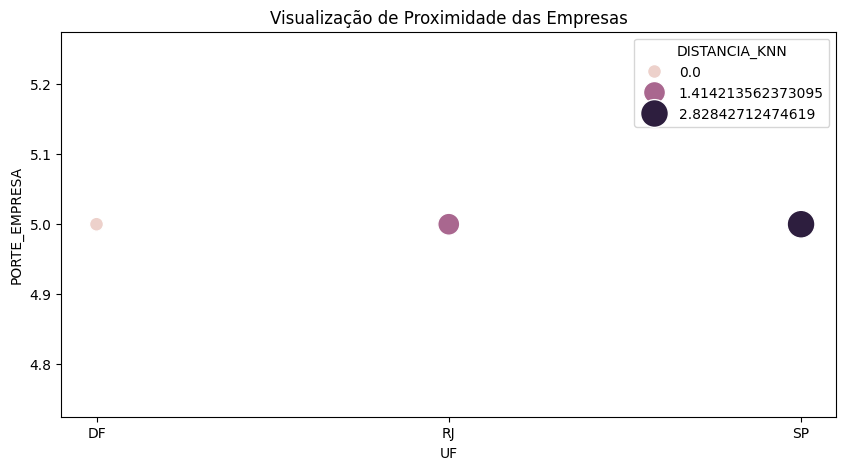

,RAZAO_SOCIAL,UF,PORTE_EMPRESA,DISTANCIA_KNN
157663,FUNDO DAS NACOES UNIDAS PARA A INFANCIA,DF,5.0,0.000000
295672,SECRETARIA-GERAL DA ORGANIZACAO DOS ESTADOS AM...,RJ,5.0,1.414214
1369638,CONSULADO GERAL AMERICANO NO RIO DE JANEIRO,RJ,5.0,1.414214
280975,CONSULADO GERAL DOS ESTADOS UNIDOS DA AMERICA ...,SP,5.0,2.828427


In [ ]:
# FUNÇÃO PRINCIPAL: ENCONTRAR EMPRESAS SEMELHANTES COM KNN
# ============================================================

def knn_empresas_final(df_pandas, pais_codigo, cnae_codigo, n_neighbors=5):

    # ------------------------------------------------
    # 1. VERIFICAÇÃO DE SEGURANÇA DAS COLUNAS
    # ------------------------------------------------
    # Alguns datasets podem ter nomes diferentes para a coluna de país.
    # Aqui verificamos qual das duas colunas existe no DataFrame.

    coluna_pais = "PAIS_JOIN" if "PAIS_JOIN" in df_pandas.columns else "PAIS_INT"

    # Caso nenhuma coluna válida exista, retornamos uma mensagem de erro
    if coluna_pais not in df_pandas.columns:
        return f"Erro: Coluna de país não encontrada. Colunas disponíveis: {list(df_pandas.columns)}"


    # ------------------------------------------------
    # 2. FILTRAGEM DOS DADOS
    # ------------------------------------------------
    # Convertendo os parâmetros para os tipos corretos
    pais_val = int(pais_codigo)
    cnae_str = str(cnae_codigo)

    # Filtro para selecionar empresas do país desejado
    mask_pais = df_pandas[coluna_pais] == pais_val

    # Filtro para CNAE principal ou secundário
    # .str.contains permite localizar o CNAE dentro da string
    mask_cnae = (
        df_pandas["CNAE_FISCAL_PRINCIPAL"].astype(str).str.contains(cnae_str)
    ) | (
        df_pandas["CNAE_FISCAL_SECUNDARIA"].astype(str).str.contains(cnae_str)
    )

    # Aplicando os filtros no DataFrame
    pdf = df_pandas[mask_pais & mask_cnae].copy()

    # Caso nenhum registro seja encontrado, retornamos aviso
    if pdf.empty:
        return f"Nenhuma empresa encontrada para o País {pais_val} e CNAE {cnae_str}."


    # ------------------------------------------------
    # 3. PREPARAÇÃO DOS DADOS PARA MACHINE LEARNING
    # ------------------------------------------------

    le = LabelEncoder()
    pdf["UF_INDEX"] = le.fit_transform(pdf["UF"].astype(str))

    # Selecionando as features que serão usadas pelo modelo
    features = ["PORTE_EMPRESA", "UF_INDEX"]

    # Convertendo para numérico e tratando valores nulos
    X = pdf[features].apply(pd.to_numeric, errors="coerce").fillna(0)

    # Padronização dos dados
    # Isso evita que variáveis com escala maior influenciem o modelo
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)


    # ------------------------------------------------
    # 4. CRIAÇÃO E TREINAMENTO DO MODELO KNN
    # ------------------------------------------------

    # Garantimos que o número de vizinhos não seja maior que o dataset
    n_vizinhos = min(n_neighbors, len(pdf))

    # Criando o modelo KNN usando distância euclidiana
    knn = NearestNeighbors(n_neighbors=n_vizinhos, metric='euclidean')

    # Treinando o modelo
    knn.fit(X_scaled)


    # ------------------------------------------------
    # 5. BUSCA DOS VIZINHOS MAIS PRÓXIMOS
    # ------------------------------------------------

    # Aqui usamos a primeira empresa do dataset como referência
    # e buscamos as empresas mais similares
    distances, indices = knn.kneighbors([X_scaled[0]])

    # Recuperando os registros encontrados
    res = pdf.iloc[indices[0]].copy()

    # Adicionando a distância calculada pelo KNN
    # Quanto menor a distância, mais similar é a empresa
    res['DISTANCIA_KNN'] = distances[0]

    return res


# ============================================================
# EXECUÇÃO DO MODELO
# ============================================================

# 'teste' deve ser o DataFrame final após merges ou transformações anteriores
resultado = knn_empresas_final(teste, pais_codigo=249, cnae_codigo=9900800)


# ============================================================
# AVALIAÇÃO E VISUALIZAÇÃO DOS RESULTADOS
# ============================================================

if isinstance(resultado, pd.DataFrame):

    # ------------------------------------------------
    # 1. MÉTRICA SIMPLES DE ASSERTIVIDADE
    # ------------------------------------------------
    # Calculamos a média das distâncias entre empresas
    # e transformamos em um indicador simples de similaridade

    dist_media = resultado['DISTANCIA_KNN'].mean()
    print(f"Assertividade: Similaridade de {max(0, 100 - (dist_media * 20)):.2f}%")


    # ------------------------------------------------
    # 2. VISUALIZAÇÃO DOS RESULTADOS
    # ------------------------------------------------
    # Criamos um gráfico para visualizar a proximidade das empresas

    plt.figure(figsize=(10, 5))

    sns.scatterplot(
        data=resultado,
        x="UF",
        y="PORTE_EMPRESA",
        hue="DISTANCIA_KNN",
        size="DISTANCIA_KNN",
        sizes=(100, 400)
    )

    plt.title("Visualização de Proximidade das Empresas")
    plt.show()


    # ------------------------------------------------
    # 3. EXIBIÇÃO FINAL DOS RESULTADOS
    # ------------------------------------------------
    # Mostramos apenas colunas relevantes para análise

    display(
        resultado[
            ["RAZAO_SOCIAL", "UF", "PORTE_EMPRESA", "DISTANCIA_KNN"]
        ]
    )

else:
    # Caso a função retorne erro ou mensagem
    print(resultado)

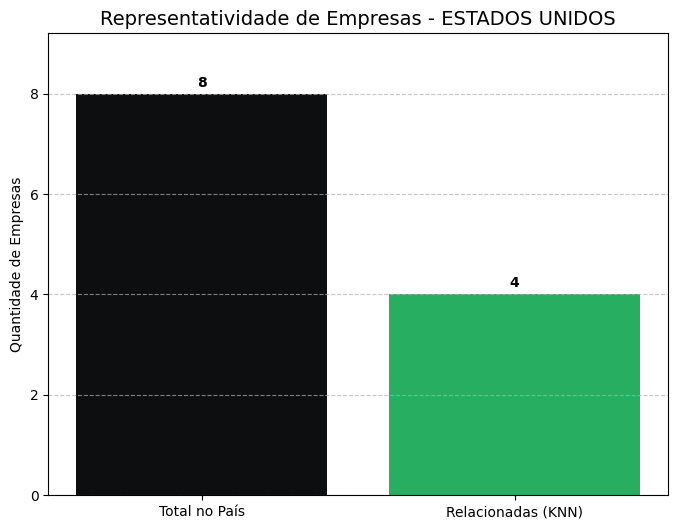

O modelo selecionou 4 empresas de um universo de 8 disponíveis no país.


,RAZAO_SOCIAL,UF,PORTE_EMPRESA,DISTANCIA_KNN
157663,FUNDO DAS NACOES UNIDAS PARA A INFANCIA,DF,5.0,0.000000
295672,SECRETARIA-GERAL DA ORGANIZACAO DOS ESTADOS AM...,RJ,5.0,1.414214
1369638,CONSULADO GERAL AMERICANO NO RIO DE JANEIRO,RJ,5.0,1.414214
280975,CONSULADO GERAL DOS ESTADOS UNIDOS DA AMERICA ...,SP,5.0,2.828427


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- EXECUÇÃO DO MODELO ---
pais_alvo = 249
cnae_alvo = 9900800
n_vizinhos_desejados = 10

resultado = knn_empresas_final(teste, pais_codigo=pais_alvo, cnae_codigo=cnae_alvo, n_neighbors=n_vizinhos_desejados)

if isinstance(resultado, pd.DataFrame):
    # 1. CÁLCULO PARA O GRÁFICO DE BARRAS
    coluna_pais = "PAIS_JOIN" if "PAIS_JOIN" in teste.columns else "PAIS_INT"

    total_pais = len(teste[teste[coluna_pais] == pais_alvo])
    total_encontrado = len(resultado)
    nome_pais = resultado['DS_PAIS'].iloc[0] if 'DS_PAIS' in resultado.columns else f"País {pais_alvo}"

    # 2. CRIANDO O GRÁFICO DE BARRAS COMPARATIVO
    plt.figure(figsize=(8, 6))
    categorias = ['Total no País', 'Relacionadas (KNN)']
    valores = [total_pais, total_encontrado]

    barras = plt.bar(categorias, valores, color=["#0c0e0f", '#27ae60'])

    for barra in barras:
        yval = barra.get_height()
        plt.text(barra.get_x() + barra.get_width()/2, yval + (total_pais*0.01),
                 int(yval), ha='center', va='bottom', fontweight='bold')

    plt.title(f"Representatividade de Empresas - {nome_pais}", fontsize=14)
    plt.ylabel("Quantidade de Empresas")
    plt.ylim(0, total_pais * 1.15) # Dá um espaço extra no topo para o texto
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.show()

    # --- EXIBIÇÃO DOS RESULTADOS ---
    print(f"O modelo selecionou {total_encontrado} empresas de um universo de {total_pais} disponíveis no país.")
    display(resultado[["RAZAO_SOCIAL", "UF", "PORTE_EMPRESA", "DISTANCIA_KNN"]])

else:
    print(resultado)